## Import necessary Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")

## Import Processed Dataset

In [24]:
df = pd.read_csv("../data/processed/cleaned_encoded_job_change_data.csv")
df.head()

,city_development_index,experience,last_new_job,training_hours,target,city_city_10,city_city_100,city_city_101,city_city_102,city_city_103,...,company_size_500-999,company_size_5000-9999,company_size_<10,company_size_nan,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_nan
0,0.920,21.0,1.0,36,1.0,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
1,0.776,15.0,5.0,47,0.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0.624,5.0,0.0,83,0.0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,0.789,0.0,0.0,52,1.0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
4,0.767,21.0,4.0,8,0.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [25]:
print("Dataset shape:", df.shape)

Dataset shape: (19158, 159)


## Separate features and target

In [26]:
X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

In [27]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (19158, 157)
Target shape: (19158,)


## Check target distribution

In [28]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

company_type_nan
False    13018
True      6140
Name: count, dtype: int64
company_type_nan
False    67.950726
True     32.049274
Name: proportion, dtype: float64


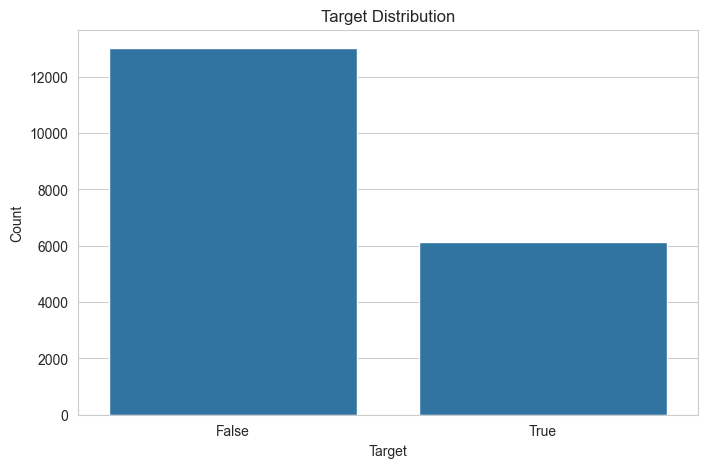

In [29]:
sns.countplot(x=y)
plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

## Train-test split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (15326, 157)
X_test shape: (3832, 157)
y_train shape: (15326,)
y_test shape: (3832,)


## Feature scaling

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Train the baseline SVM model

In [33]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

imputer = SimpleImputer(strategy="mean")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)


svm_model = SVC(random_state=42, probability=True)
svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## Make predictions

In [34]:
y_pred = svm_model.predict(X_test_scaled)
y_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

## Evaluate the baseline model

In [35]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.9543
Precision: 0.927
Recall   : 0.9308
F1-score : 0.9289
ROC-AUC  : 0.9914


## Classification report

In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.97      0.97      0.97      2604
        True       0.93      0.93      0.93      1228

    accuracy                           0.95      3832
   macro avg       0.95      0.95      0.95      3832
weighted avg       0.95      0.95      0.95      3832



## Confusion matrix

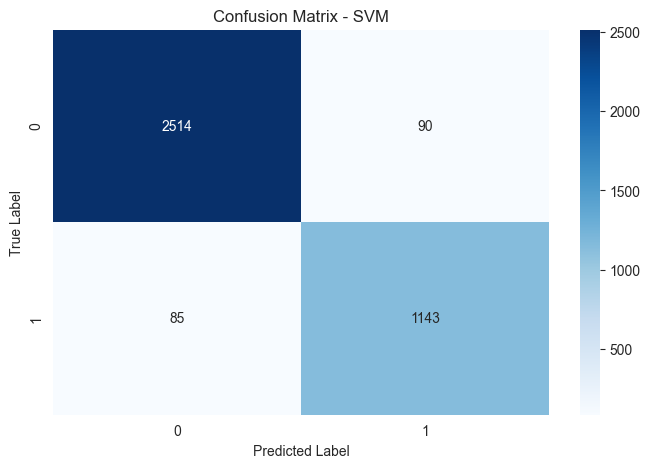

In [37]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## ROC curve

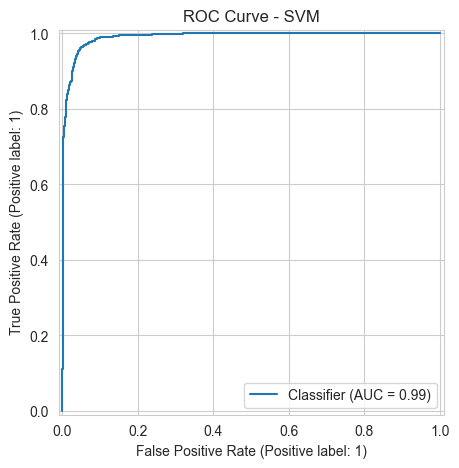

In [38]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve - SVM")
plt.show()

## Cross-validation score

In [39]:
cv_scores = cross_val_score(
    SVC(random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean CV F1 score:", cv_scores.mean())

Cross-validation F1 scores: [0.9356962  0.93788187 0.94475418 0.95146613 0.93509128]
Mean CV F1 score: 0.9409779326000368


## Hyperparameter tuning

In [40]:
param_grid = { "C": [0.1, 1, 5], "kernel": ["linear", "rbf"], "gamma": ["scale", "auto"], "class_weight": [None, "balanced"] }

In [41]:
grid_search = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

/Users/nuwandharmarathna/miniconda3/envs/stocks-env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/nuwandharmarathna/miniconda3/envs/stocks-env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/nuwandharmarathna/miniconda3/envs/stocks-env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated f

,estimator,SVC(probabili...ndom_state=42)
,param_grid,"{'C': [0.1, 1, ...], 'class_weight': [None, 'balanced'], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.1


In [42]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1 Score:", grid_search.best_score_)

Best Parameters: {'C': 0.1, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation F1 Score: 0.9758279369079416


## Train the tuned model

In [43]:
best_svm = grid_search.best_estimator_
best_svm.fit(X_train_scaled, y_train)

,C,0.1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## Predict with tuned model

In [44]:
y_pred_best = best_svm.predict(X_test_scaled)
y_prob_best = best_svm.predict_proba(X_test_scaled)[:, 1]

## Evaluate tuned model

In [45]:
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_prob_best)

print("Tuned SVM Performance")
print("Accuracy :", round(accuracy_best, 4))
print("Precision:", round(precision_best, 4))
print("Recall   :", round(recall_best, 4))
print("F1-score :", round(f1_best, 4))
print("ROC-AUC  :", round(roc_auc_best, 4))

Tuned SVM Performance
Accuracy : 0.9807
Precision: 0.973
Recall   : 0.9666
F1-score : 0.9698
ROC-AUC  : 0.9975


## Classification report for tuned model

In [46]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

       False       0.98      0.99      0.99      2604
        True       0.97      0.97      0.97      1228

    accuracy                           0.98      3832
   macro avg       0.98      0.98      0.98      3832
weighted avg       0.98      0.98      0.98      3832



## Confusion matrix for tuned model

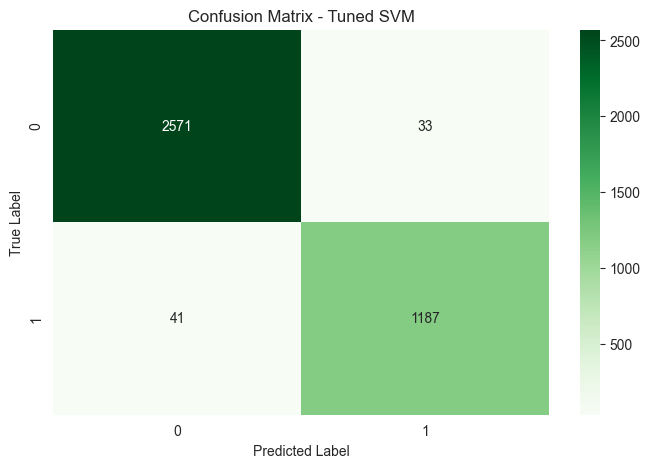

In [47]:
cm_best = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm_best, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Tuned SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## ROC curve for tuned model

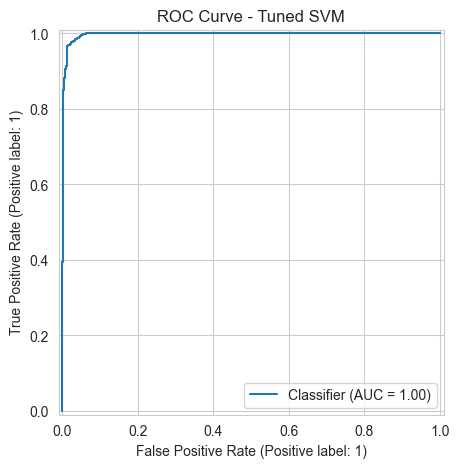

In [48]:
RocCurveDisplay.from_predictions(y_test, y_prob_best)
plt.title("ROC Curve - Tuned SVM")
plt.show()

## Compare baseline and tuned model

In [49]:
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Baseline": [accuracy, precision, recall, f1, roc_auc],
    "Tuned Model": [accuracy_best, precision_best, recall_best, f1_best, roc_auc_best]
})

comparison_df

,Metric,Baseline,Tuned Model
0,Accuracy,0.954332,0.980689
1,Precision,0.927007,0.972951
2,Recall,0.930782,0.966612
3,F1-score,0.928891,0.969771
4,ROC-AUC,0.991442,0.997515
